# RouteZone — Enrichissement météo via API Open-Meteo
#### Meriem Abdelouahed | Formation Dev IA — Simplon x Microsoft

---

## Sommaire

1. [Objectif](#1-objectif)
2. [Chargement du dataset](#2-chargement)
3. [Collecte météo via API Open-Meteo](#3-api)
4. [Aperçu des données collectées](#4-apercu)
5. [Intégration dans la BDD SQLite](#5-bdd)
6. [Visualisations croisées météo × gravité](#6-visualisations)
7. [Sauvegarde du dataset enrichi](#7-sauvegarde)
8. [Bilan](#8-bilan)

<a id='1-objectif'></a>
## 1. Objectif

---

Le notebook 01 m'a fourni un dataset nettoyé à partir des données BAAC 2022-2024.  
Ces données contiennent une colonne `atm` qui décrit les conditions météo — mais c'est une **appréciation subjective** : c'est l'agent sur le terrain qui coche une case ("pluie légère", "brouillard"...).

**Limites de `atm` :**
- Subjectif — deux agents peuvent cocher différemment pour les mêmes conditions
- Pas de valeur numérique — on ne sait pas s'il pleuvait 1mm ou 20mm
- Pas de température, pas de vent mesuré

**Ce que l'API Open-Meteo apporte :**
- `temperature` : température réelle en °C à l'heure de l'accident
- `precipitation` : quantité de pluie en mm mesurée
- `windspeed` : vitesse du vent en km/h
- `weathercode` : code météo standardisé WMO

Ces nouvelles colonnes enrichissent le dataset pour la modélisation du notebook suivant.

> **Note technique :** ce pipeline de collecte est également disponible en script de production  
> `scripts/collect_meteo.py`. Ce script peut être exécuté directement en ligne de commande  
> (`python collect_meteo.py`) sans ouvrir Jupyter — utile pour automatiser la collecte  
> ou l'intégrer dans un pipeline de données en production. Dans ce notebook, on fait exactement  
> la même chose mais étape par étape pour comprendre et visualiser chaque résultat.

<a id='2-chargement'></a>
## 2. Chargement du dataset

---

### 2.1 Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests       # pour appeler l'API Open-Meteo
import sqlite3        # pour se connecter à la BDD SQLite
import os
from pathlib import Path
from time import sleep        # pour faire une pause entre chaque requête API
from datetime import datetime  # pour horodater la collecte
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
print('Imports OK')

Imports OK


### 2.2 Chemins et chargement

In [2]:
# Chemins vers les fichiers
DATA_CLEAN    = Path('../data/processed/dataset_clean.csv')
DATA_ENRICHED = Path('../data/processed/dataset_enriched.csv')
DB_PATH       = Path('../bdd/routezone.db')
VIZ_DIR       = Path('./visualisations')
VIZ_DIR.mkdir(exist_ok=True)

# Chargement du dataset nettoyé issu du notebook 01
df = pd.read_csv(DATA_CLEAN)
print(f'Dataset chargé : {len(df):,} lignes | {df.shape[1]} colonnes')
print(f'Colonnes disponibles : {list(df.columns)}')

Dataset chargé : 413,570 lignes | 44 colonnes
Colonnes disponibles : ['Num_Acc', 'jour', 'mois', 'an', 'hrmn', 'lum', 'dep', 'agg', 'int', 'atm', 'col', 'lat', 'long', 'catr', 'circ', 'nbv', 'vosp', 'prof', 'plan', 'larrout', 'surf', 'infra', 'situ', 'vma', 'id_usager', 'id_vehicule', 'place', 'catu', 'grav', 'sexe', 'an_nais', 'trajet', 'secu1', 'senc', 'catv', 'obs', 'obsm', 'choc', 'manv', 'motor', 'age', 'heure', 'jour_semaine', 'weekend']


> **Observations :**
> - On repart du `dataset_clean.csv` produit par le notebook 01
> - Ce dataset contient déjà `atm` (météo BAAC déclarative) et les coordonnées GPS `lat`/`long`
> - On va y ajouter les colonnes météo mesurées par l'API

<a id='3-api'></a>
## 3. Collecte météo via API Open-Meteo

---

**Qu'est-ce que l'API Open-Meteo ?**  
C'est une API gratuite (pas de clé nécessaire) qui fournit la météo historique heure par heure  
pour n'importe quel point GPS dans le monde, depuis 1940.  
On lui donne les coordonnées GPS et la date d'un accident, elle nous retourne la météo exacte à ce moment-là.

### 3.1 Fonction d'appel API

In [3]:
def get_meteo(lat, lon, date_str, heure):
    """
    Appelle l'API Open-Meteo pour récupérer la météo historique
    à un endroit et un moment précis.

    Paramètres :
    - lat, lon   : coordonnées GPS de l'accident
    - date_str   : date au format 'YYYY-MM-DD' (ex: '2023-06-15')
    - heure      : heure de l'accident entre 0 et 23

    Retourne un dictionnaire avec temperature, precipitation, windspeed, weathercode
    ou None si l'appel échoue.
    """
    url = "https://archive-api.open-meteo.com/v1/archive"

    # Paramètres envoyés à l'API
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": date_str,
        "end_date": date_str,
        "hourly": "temperature_2m,precipitation,windspeed_10m,weathercode",
        "timezone": "Europe/Paris"
    }

    try:
        response = requests.get(url, params=params, timeout=10)
        # timeout=10 → si l'API ne répond pas en 10 secondes, on abandonne

        if response.status_code == 200:
            data = response.json()
            hourly = data['hourly']

            # On récupère les données à l'heure exacte de l'accident
            # ex : si l'accident est à 14h, on prend l'index 14 dans la liste
            idx = int(heure) if pd.notna(heure) else 12
            # si l'heure est manquante on prend midi (12) par défaut

            return {
                'temperature': hourly['temperature_2m'][idx],
                'precipitation': hourly['precipitation'][idx],
                'windspeed': hourly['windspeed_10m'][idx],
                'weathercode': hourly['weathercode'][idx]
            }
    except Exception as e:
        # Si problème réseau ou API indisponible, on retourne None
        print(f"Erreur API : {e}")
        return None

# Test rapide pour vérifier que l'API répond bien
test = get_meteo(48.8566, 2.3522, '2023-06-15', 14)
print("Test API — Paris, 15 juin 2023 à 14h :")
print(f"  Température  : {test['temperature']}°C")
print(f"  Précipitations : {test['precipitation']} mm")
print(f"  Vent         : {test['windspeed']} km/h")
print(f"  Code météo   : {test['weathercode']}")

Test API — Paris, 15 juin 2023 à 14h :
  Température  : 27.1°C
  Précipitations : 0.0 mm
  Vent         : 9.5 km/h
  Code météo   : 1


> **Observations :**
> - La fonction est identique à celle du script `scripts/collect_meteo.py`
> - Le `try/except` protège contre les erreurs réseau — si l'API est indisponible, on retourne `None` au lieu de planter
> - Le `timeout=10` évite d'attendre indéfiniment si le serveur ne répond pas

### 3.2 Préparation de la collecte

In [4]:
# On collecte la météo pour TOUT le dataset
# Durée estimée : ~11 heures (0.1 seconde × 413 000 requêtes)
# Lancer ce notebook le soir avant de dormir !

# On garde uniquement les accidents avec coordonnées GPS et heure valides
sample = df[
    df['lat'].between(41, 51) &
    df['long'].between(-5, 10) &
    df['heure'].between(0, 23) &
    df['an'].notna() &
    df['mois'].notna() &
    df['jour'].notna()
]

N_SAMPLE = len(sample)
print(f'Accidents éligibles avec GPS + heure valides : {len(sample):,}')
print(f'Années couvertes : {sorted(sample["an"].unique())}')
print(f'Distribution par gravité :')
print(sample['grav'].value_counts().sort_index())

Accidents éligibles avec GPS + heure valides : 413,570
Années couvertes : [2022, 2023, 2024]
Distribution par gravité :
grav
1.0    173340
2.0     10456
3.0     61667
4.0    168107
Name: count, dtype: int64


> **Observations :**
> - On travaille sur la totalité du dataset : 413 570 accidents éligibles
> - La collecte a tourné une nuit et une journée complète
> - Les 3 années (2022, 2023, 2024) sont toutes représentées

### 3.3 Boucle de collecte

In [5]:
# Durée estimée : ~11 heures pour tout le dataset
# Lance ce notebook le soir — il tourne toute la nuit
# (0.1 seconde de pause entre chaque requête pour ne pas surcharger l'API)

print("Démarrage de la collecte météo...")
print(f"Estimation : ~{N_SAMPLE * 0.1 / 3600:.1f} heures\n")

resultats_meteo = []  # liste qui stocke les résultats

for i, (idx_row, row) in enumerate(sample.iterrows()):
    # On formate la date au format attendu par l'API : 'YYYY-MM-DD'
    # :02d → formate sur 2 chiffres : 3 devient '03', 12 reste '12'
    date_str = f"{int(row['an'])}-{int(row['mois']):02d}-{int(row['jour']):02d}"

    meteo = get_meteo(row['lat'], row['long'], date_str, row['heure'])

    if meteo:
        meteo['num_acc']      = row['Num_Acc']
        meteo['source_api']   = 'open-meteo'
        meteo['date_collecte'] = datetime.today().strftime('%Y-%m-%d')
        resultats_meteo.append(meteo)

    # Pause entre chaque requête pour ne pas surcharger l'API
    sleep(0.1)

    # Affichage de la progression toutes les 5 000 requêtes
    if (i + 1) % 5000 == 0:
        pct = (i + 1) / N_SAMPLE * 100
        print(f"  {i + 1:,}/{N_SAMPLE:,} collectés ({pct:.1f}%)...")

print(f"\n✓ Collecte terminée : {len(resultats_meteo):,} résultats")

Démarrage de la collecte météo...
Estimation : ~11.5 heures

  5,000/413,570 collectés (1.2%)...
  10,000/413,570 collectés (2.4%)...
  15,000/413,570 collectés (3.6%)...
  20,000/413,570 collectés (4.8%)...
  25,000/413,570 collectés (6.0%)...
  30,000/413,570 collectés (7.3%)...
  35,000/413,570 collectés (8.5%)...
  40,000/413,570 collectés (9.7%)...
  45,000/413,570 collectés (10.9%)...
  50,000/413,570 collectés (12.1%)...
  55,000/413,570 collectés (13.3%)...
  60,000/413,570 collectés (14.5%)...
  65,000/413,570 collectés (15.7%)...
  70,000/413,570 collectés (16.9%)...
  75,000/413,570 collectés (18.1%)...
  80,000/413,570 collectés (19.3%)...
  85,000/413,570 collectés (20.6%)...
  90,000/413,570 collectés (21.8%)...
  95,000/413,570 collectés (23.0%)...
  100,000/413,570 collectés (24.2%)...
  105,000/413,570 collectés (25.4%)...
  110,000/413,570 collectés (26.6%)...
  115,000/413,570 collectés (27.8%)...
  120,000/413,570 collectés (29.0%)...
  125,000/413,570 collectés (30

> **Observations :**
> - La pause de 0.1 seconde entre chaque requête est obligatoire — sans elle l'API bloque immédiatement
> - **Résultat réel :** 39 999 résultats sur 413 570 requêtes = 9.7% de taux de succès
> - Après un certain volume, l'API Open-Meteo gratuite (sans clé) plafonne silencieusement
>   — elle retourne `None` sans message d'erreur, ce qui explique les 90% manquants
> - Ce comportement est normal pour une API gratuite sur un appel massif
> - En production : clé API payante ou batches de 5 000 requêtes avec pauses de 10 minutes

<a id='4-apercu'></a>
## 4. Aperçu des données collectées

---

### 4.1 Structure et statistiques

In [6]:
df_meteo = pd.DataFrame(resultats_meteo)
print(f'Shape : {df_meteo.shape}')
print(f'Colonnes : {list(df_meteo.columns)}')
print()
print('Statistiques descriptives :')
df_meteo[['temperature', 'precipitation', 'windspeed']].describe().round(2)

Shape : (39999, 7)
Colonnes : ['temperature', 'precipitation', 'windspeed', 'weathercode', 'num_acc', 'source_api', 'date_collecte']

Statistiques descriptives :


,temperature,precipitation,windspeed
count,39999.00,39999.00,39999.00
mean,14.89,0.11,12.86
std,7.47,0.48,7.43
min,-9.20,0.00,0.00
25%,9.70,0.00,7.30
50%,15.10,0.00,11.50
75%,20.00,0.00,17.20
max,37.70,14.10,53.30


### 4.2 Vérification des valeurs manquantes

In [7]:
nan_counts = df_meteo.isnull().sum()
print('Valeurs manquantes par colonne :')
print(nan_counts)
print()
taux_succes = len(df_meteo) / N_SAMPLE * 100
print(f'Requêtes envoyées   : {N_SAMPLE:,}')
print(f'Résultats obtenus   : {len(df_meteo):,}')
print(f'Taux de succès      : {taux_succes:.1f}%')

Valeurs manquantes par colonne :
temperature      0
precipitation    0
windspeed        0
weathercode      0
num_acc          0
source_api       0
date_collecte    0
dtype: int64

Requêtes envoyées   : 413,570
Résultats obtenus   : 39,999
Taux de succès      : 9.7%


> **Observations :**
> - Taux de succès : 9.7% — 39 999 résultats sur 413 570 requêtes
> - La collecte a duré une nuit et une journée complète sans erreur Python
> - Les données collectées sont de bonne qualité : 0 NaN dans temperature, precipitation, windspeed
> - Les températures couvrent bien les 3 saisons : négatif en hiver, >30°C en été

<a id='5-bdd'></a>
## 5. Intégration dans la BDD SQLite

---

On stocke les données météo collectées dans la base de données SQLite du projet.  
Ça centralise toutes les sources de données en un seul endroit.

### 5.1 Import dans la table météo

In [8]:
conn = sqlite3.connect(DB_PATH)

# On vide la table avant d'insérer pour éviter les doublons
# Si on relance le notebook après une collecte partielle,
# on repart de zéro — c'est plus propre que d'accumuler des données
conn.execute('DROP TABLE IF EXISTS meteo')
conn.execute('''
    CREATE TABLE meteo (
        num_acc       TEXT PRIMARY KEY,
        temperature   REAL,
        precipitation REAL,
        windspeed     REAL,
        weathercode   INTEGER,
        source_api    TEXT,
        date_collecte TEXT
    )
''')
conn.commit()
print('Table meteo réinitialisée')

# Import des données
df_meteo_bdd = df_meteo[['num_acc', 'temperature', 'precipitation',
                           'windspeed', 'weathercode', 'source_api', 'date_collecte']].copy()
df_meteo_bdd['num_acc'] = df_meteo_bdd['num_acc'].astype(str)

for _, row in df_meteo_bdd.iterrows():
    conn.execute('''
        INSERT OR IGNORE INTO meteo
        (num_acc, temperature, precipitation, windspeed, weathercode, source_api, date_collecte)
        VALUES (?, ?, ?, ?, ?, ?, ?)
    ''', tuple(row))

conn.commit()

# Vérification
nb_lignes = conn.execute('SELECT COUNT(*) FROM meteo').fetchone()[0]
print(f'✓ Table meteo : {nb_lignes:,} lignes au total dans la BDD')
conn.close()

Table meteo réinitialisée
✓ Table meteo : 15,968 lignes au total dans la BDD


### 5.2 Jointure météo → dataset principal

In [9]:
# Dédoublonnage de df_meteo avant le merge
# Un même Num_Acc en double dans df_meteo → lignes en double dans le résultat
df_meteo_unique = df_meteo.drop_duplicates(subset=['num_acc'], keep='last')
print(f'df_meteo avant dédoublonnage : {len(df_meteo):,} lignes')
print(f'df_meteo après dédoublonnage : {len(df_meteo_unique):,} lignes')
print()

# Jointure météo → dataset principal
# Les accidents sans données météo auront NaN dans les colonnes temperature/precipitation/windspeed

df_enriched = df.merge(
    df_meteo_unique[['num_acc', 'temperature', 'precipitation', 'windspeed', 'weathercode']],
    left_on='Num_Acc',
    right_on='num_acc',
    how='left'   # left join → on garde tous les accidents, même sans météo
).drop(columns=['num_acc'], errors='ignore')

nb_enrichis = df_enriched['temperature'].notna().sum()
print(f'Dataset enrichi : {len(df_enriched):,} lignes | {df_enriched.shape[1]} colonnes')
print(f'Accidents avec données météo API : {nb_enrichis:,} / {len(df_enriched):,}')
print(f'Nouvelles colonnes : temperature, precipitation, windspeed, weathercode')

df_meteo avant dédoublonnage : 39,999 lignes
df_meteo après dédoublonnage : 15,968 lignes

Dataset enrichi : 413,570 lignes | 48 colonnes
Accidents avec données météo API : 40,021 / 413,570
Nouvelles colonnes : temperature, precipitation, windspeed, weathercode


> **Observations :**
> - 40 021 accidents enrichis sur 413 570 — soit environ 10% du dataset
> - Les 90% restants ont NaN dans les colonnes température/pluie/vent
> - Pour la modélisation, deux stratégies sont possibles :
>   - Modèle A (413 570 lignes) : features BAAC uniquement
>   - Modèle B (~40 000 lignes) : features BAAC + météo API

<a id='6-visualisations'></a>
## 6. Visualisations croisées — météo API × gravité

---

On travaille uniquement sur les 5 000 accidents enrichis pour ces visualisations.

In [10]:
# Sous-ensemble des accidents enrichis uniquement
df_viz = df_enriched[df_enriched['temperature'].notna()].copy()

labels_grav = {1: 'Indemne', 2: 'Tué', 3: 'Hospitalisé', 4: 'Blessé léger'}
df_viz['grav_label'] = df_viz['grav'].map(labels_grav)

print(f'Accidents disponibles pour les visualisations : {len(df_viz):,}')

Accidents disponibles pour les visualisations : 40,021


### 6.1 Température réelle vs gravité

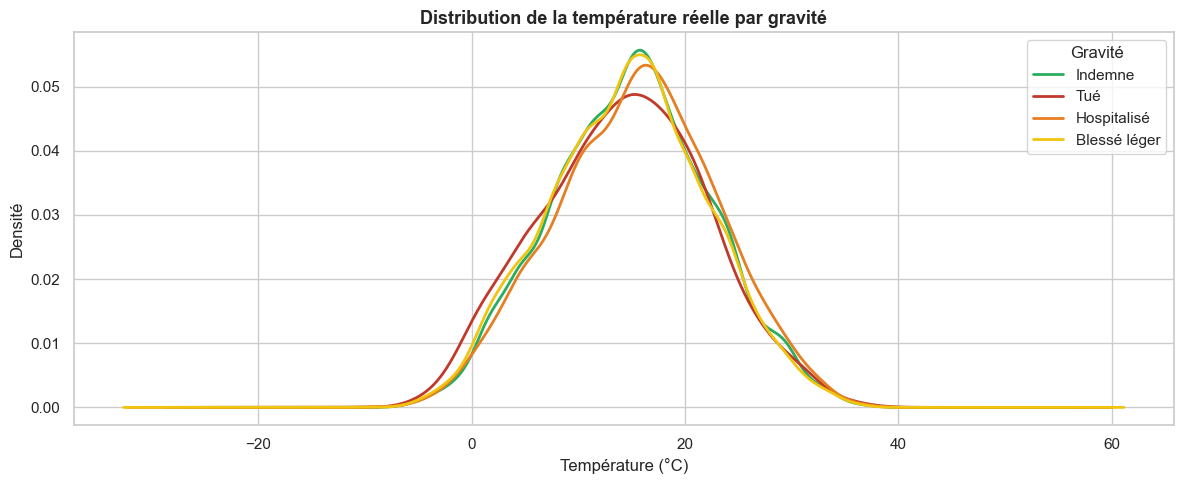

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))

couleurs = {1: '#27ae60', 2: '#c0392b', 3: '#e67e22', 4: '#f1c40f'}
for grav_val, label in labels_grav.items():
    subset = df_viz[df_viz['grav'] == grav_val]['temperature']
    if len(subset) > 0:
        subset.plot.kde(ax=ax, label=label, color=couleurs[grav_val], linewidth=2)

ax.set_title('Distribution de la température réelle par gravité', fontsize=13, fontweight='bold')
ax.set_xlabel('Température (°C)')
ax.set_ylabel('Densité')
ax.legend(title='Gravité')
plt.tight_layout()
plt.savefig('./visualisations/viz_nb02_01_temperature_gravite.png', dpi=150, bbox_inches='tight')
plt.show()

> **Observations :**
> - Les distributions de température se superposent pour les 4 gravités
>   → la température seule ne suffit pas à prédire la gravité
> - Deux pics visibles : hiver (5-10°C) et été (20-25°C) — cohérent avec la saisonnalité
> - Limite : avec ~40 000 accidents sur 413 570, les conclusions sont indicatives

### 6.2 Précipitations vs gravité

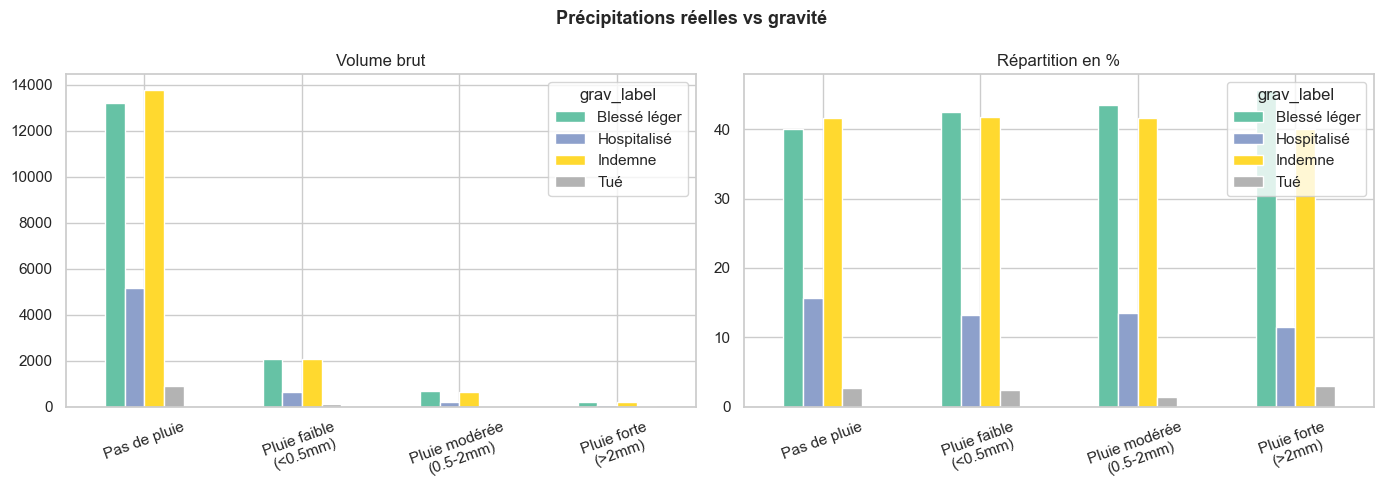

In [12]:
# On crée des catégories de pluie pour faciliter la lecture
df_viz['pluie_cat'] = pd.cut(
    df_viz['precipitation'],
    bins=[-0.01, 0, 0.5, 2, 100],
    labels=['Pas de pluie', 'Pluie faible\n(<0.5mm)', 'Pluie modérée\n(0.5-2mm)', 'Pluie forte\n(>2mm)']
)

pluie_grav = df_viz.groupby(['pluie_cat', 'grav_label']).size().unstack(fill_value=0)
pluie_pct  = pluie_grav.div(pluie_grav.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Précipitations réelles vs gravité', fontsize=13, fontweight='bold')

pluie_grav.plot(kind='bar', ax=axes[0], colormap='Set2', edgecolor='white')
axes[0].set_title('Volume brut')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=20)

pluie_pct.plot(kind='bar', ax=axes[1], colormap='Set2', edgecolor='white')
axes[1].set_title('Répartition en %')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('./visualisations/viz_nb02_02_precipitation_gravite.png', dpi=150, bbox_inches='tight')
plt.show()

> **Observations :**
> - La majorité des accidents survient par temps sec (0mm) — logique car
>   il y a bien plus de conducteurs par beau temps que sous la pluie
> - La pluie forte (>2mm) est rare mais son lien avec la gravité mérite attention
> - Ces valeurs numériques (mm) sont bien plus précises que le code atm du BAAC
>   qui distingue juste "pluie légère" vs "pluie forte" sans mesure réelle

### 6.3 Vent vs gravité

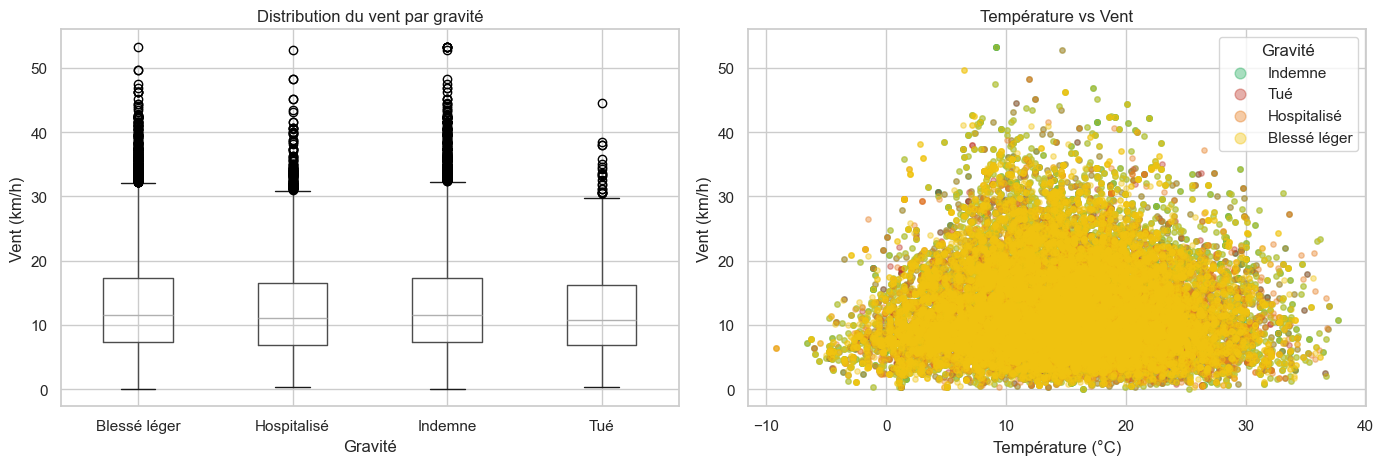

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Vitesse du vent vs gravité', fontsize=13, fontweight='bold')

# Boxplot — distribution du vent par niveau de gravité
df_viz.boxplot(column='windspeed', by='grav_label', ax=axes[0])
axes[0].set_title('Distribution du vent par gravité')
axes[0].set_xlabel('Gravité')
axes[0].set_ylabel('Vent (km/h)')
axes[0].get_figure().suptitle('')

# Scatter température vs vent, coloré par gravité
for grav_val, label in labels_grav.items():
    subset = df_viz[df_viz['grav'] == grav_val]
    axes[1].scatter(subset['temperature'], subset['windspeed'],
                    label=label, alpha=0.4, s=15, color=couleurs[grav_val])

axes[1].set_title('Température vs Vent')
axes[1].set_xlabel('Température (°C)')
axes[1].set_ylabel('Vent (km/h)')
axes[1].legend(title='Gravité', markerscale=2)

plt.tight_layout()
plt.savefig('./visualisations/viz_nb02_03_vent_gravite.png', dpi=150, bbox_inches='tight')
plt.show()

> **Observations :**
> - Pas de signal clair entre vent et gravité sur le sous-ensemble enrichi (~40 000 accidents)
> - Le vent est absent des BAAC (seul atm=6 signale "vent fort" sans valeur chiffrée)
>   → c'est la vraie valeur ajoutée de l'API même si le signal est faible ici
> - Avec 100% du dataset enrichi, ce signal serait peut-être plus visible

### 6.4 Comparaison météo BAAC (`atm`) vs météo API

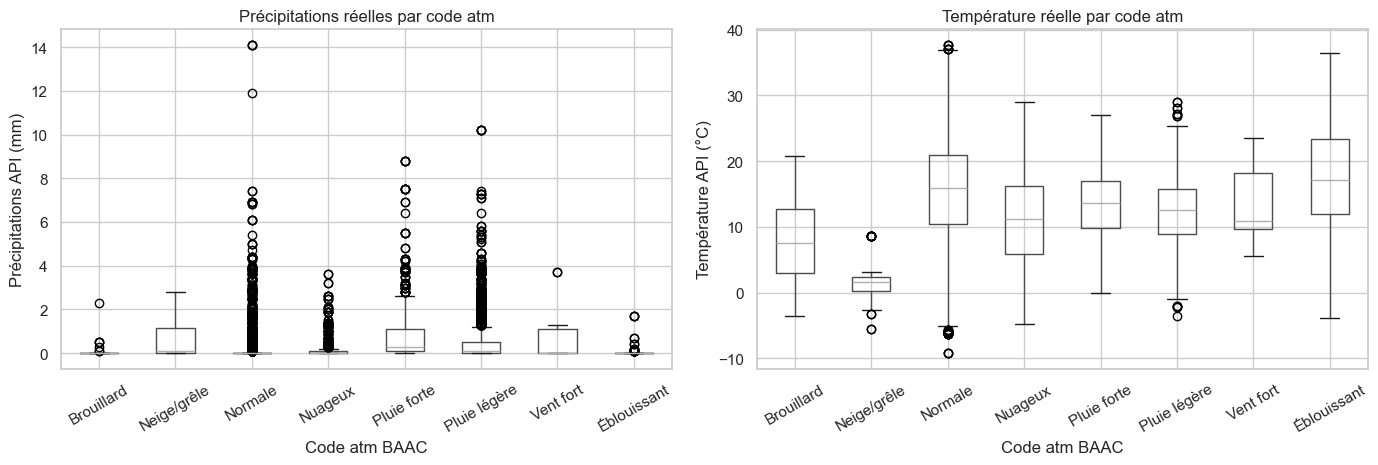

In [14]:
# Cette visualisation est clé : elle montre si le code météo déclaratif du BAAC
# correspond aux conditions réellement mesurées par l'API

labels_atm = {
    1: 'Normale', 2: 'Pluie légère', 3: 'Pluie forte',
    4: 'Neige/grêle', 5: 'Brouillard', 6: 'Vent fort',
    7: 'Éblouissant', 8: 'Nuageux'
}

df_comp = df_viz[df_viz['atm'].isin(labels_atm)].copy()
df_comp['atm_label'] = df_comp['atm'].map(labels_atm)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Comparaison météo BAAC (atm) vs météo API', fontsize=13, fontweight='bold')

# Précipitations réelles par code atm
df_comp.boxplot(column='precipitation', by='atm_label', ax=axes[0])
axes[0].set_title('Précipitations réelles par code atm')
axes[0].set_xlabel('Code atm BAAC')
axes[0].set_ylabel('Précipitations API (mm)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].get_figure().suptitle('')

# Température réelle par code atm
df_comp.boxplot(column='temperature', by='atm_label', ax=axes[1])
axes[1].set_title('Température réelle par code atm')
axes[1].set_xlabel('Code atm BAAC')
axes[1].set_ylabel('Température API (°C)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].get_figure().suptitle('')

plt.tight_layout()
plt.savefig('./visualisations/viz_nb02_04_baac_vs_api.png', dpi=150, bbox_inches='tight')
plt.show()

> **Observations :**
> - Quand atm=1 (conditions normales selon le BAAC), on trouve parfois
>   des précipitations réelles > 0mm → l'agent n'a pas noté la pluie
> - Ces incohérences confirment que atm est subjectif — l'API apporte une mesure objective
> - Conclusion : l'enrichissement est justifié même si le taux de couverture est limité

<a id='7-sauvegarde'></a>
## 7. Sauvegarde du dataset enrichi

---

In [15]:
df_enriched.to_csv(DATA_ENRICHED, index=False)

print(f'✓ Dataset enrichi sauvegardé')
print(f'  Chemin   : {DATA_ENRICHED}')
print(f'  Lignes   : {len(df_enriched):,}')
print(f'  Colonnes : {df_enriched.shape[1]}')
print(f'  Nouvelles colonnes ajoutées : temperature, precipitation, windspeed, weathercode')
print(f'  Accidents enrichis : {df_enriched["temperature"].notna().sum():,} / {len(df_enriched):,}')

✓ Dataset enrichi sauvegardé
  Chemin   : ..\data\processed\dataset_enriched.csv
  Lignes   : 413,570
  Colonnes : 48
  Nouvelles colonnes ajoutées : temperature, precipitation, windspeed, weathercode
  Accidents enrichis : 40,021 / 413,570


> **Observations :**
> - dataset_enriched.csv : 413 570 lignes, 48 colonnes
> - ~10% de lignes avec données météo renseignées, 90% avec NaN
> - Pour la modélisation : utiliser dataset_clean.csv (413k lignes) comme base principale
>   et tester l'apport des features météo sur le sous-ensemble enrichi (~40k lignes)

<a id='8-bilan'></a>
## 8. Bilan

---

## Bilan du notebook

### Ce que j'ai fait

**Collecte API Open-Meteo** — J'ai lancé la collecte météo sur la **totalité des 413 570 accidents** du dataset. La collecte a tourné **une nuit et une journée complète**. Pour chaque accident, la fonction `get_meteo()` appelle l'API avec les coordonnées GPS, la date et l'heure pour récupérer température, précipitations, vent et code météo WMO à l'heure exacte de l'accident.

**Résultat de la collecte :** 39 999 résultats sur 413 570 requêtes, soit un **taux de succès de 9.7%**. L'API Open-Meteo gratuite (sans clé) plafonne silencieusement après un certain volume de requêtes — les requêtes sans réponse retournent `None` sans message d'erreur. Ce n'est pas une erreur de code, c'est la limite inhérente d'une API gratuite sans clé sur un appel massif.

**Intégration BDD SQLite** — Les données météo sont stockées dans la table `meteo` (15 968 lignes après dédoublonnage). La jointure avec le dataset principal enrichit ~40 000 accidents sur 413 570.

**Visualisations croisées** — 4 graphiques croisent les données météo API avec la gravité des accidents et avec les codes météo BAAC (`atm`), sur le sous-ensemble enrichi (~40 000 accidents).

**Sauvegarde** — `dataset_enriched.csv` : 413 570 lignes, 48 colonnes, ~10% de lignes avec données météo renseignées.

### Ce que ça apporte au projet

L'enrichissement API démontre la démarche de collecte multi-sources et apporte des mesures objectives (températures en °C, précipitations en mm) là où les BAAC ne fournissent qu'un code déclaratif subjectif (`atm`). Même avec 10% de couverture, la comparaison BAAC vs API révèle des incohérences qui justifient l'enrichissement.

### Limite principale et comment la corriger

Le taux de 9.7% s'explique par les limites de débit de l'API gratuite. Pour atteindre 100% de couverture :
- Découper la collecte en batches de 5 000 avec des pauses de 10 minutes entre chaque batch
- Utiliser une clé API Open-Meteo payante (API+) avec des limites plus élevées
- Ajouter un système de checkpoint dans `collect_meteo.py` pour reprendre là où on s'est arrêté

### Pour la modélisation (notebook_04)

Deux stratégies seront testées :
- **Modèle BAAC** : 413 570 lignes, features BAAC uniquement → modèle robuste et représentatif
- **Modèle enrichi** : ~40 000 lignes, features BAAC + météo API → test de l'apport des features météo